In [16]:
import sys
import matplotlib.pyplot as plt
import numpy as np
sys.path.append('/home/sc/espnet/egs2/12m/spk1')

# Import everything from view_data.py
from view_data import *

print("All functions imported successfully")

All functions imported successfully


In [22]:
# Quick overview of your dataset
quick_stats()

✅ Connected to database successfully!

🏆 Top 10 singers
----------------
singer_id  files
  id00043   2117
  id00027   1586
  id00040   1556
  id00021   1080
  id00039    700
  id00044    700
  id00011    543
  id00030    509
  id00041    474
  id00057    422

📊 Database summary
------------------
 total_embeddings  unique_singers            first_processed             last_processed
            14979              58 2025-06-18 15:36:30.411544 2025-06-19 16:53:48.332697

📈 File count distribution
-------------------------
  range  singers
   500+        8
200-499       10
100-199       15
  50-99        8
    <50       17


/home/sc/espnet/egs2/12m/spk1/view_data.py:151: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  try: print(pd.read_sql(q,conn).to_string(index=False))
/home/sc/espnet/egs2/12m/spk1/view_data.py:151: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  try: print(pd.read_sql(q,conn).to_string(index=False))
/home/sc/espnet/egs2/12m/spk1/view_data.py:151: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  try: print(pd.read_sql(q,conn).to_string(index=False))


In [ ]:
# Connect and show basic statistics
conn = connect_to_database()
show_basic_stats(conn)
list_all_singers(conn)
conn.close()

✅ Connected to database successfully!

📊 YOUR DATA SUMMARY:
Total audio files processed: 14979
Number of different singers : 58
Average files per singer   : 258.3

👥 ALL SINGERS:
Singer ID        | Number of Files
-----------------------------------
id00043         | 2117
id00027         | 1586
id00040         | 1556
id00021         | 1080
id00039         | 700
id00044         | 700
id00011         | 543
id00030         | 509
id00041         | 474
id00057         | 422
id00046         | 376
id00038         | 348
id00022         | 339
id00015         | 313
id00010         | 275
id00014         | 272
id00042         | 233
id00019         | 231
id00003         | 188
id00028         | 180
id00009         | 176
id00002         | 169
id00016         | 158
id00001         | 150
id00013         | 141
id00020         | 130
id00055         | 129
id00033         | 128
id00035         | 125
id00058         | 116
id00025         | 114
id00051         | 108
id00024         | 100
id00031         | 94

In [23]:
# Explore embeddings in detail
embeddings_data = explore_embeddings(n_samples=10)

✅ Connected to database successfully!
✅ Analyzed 10 embeddings dim=192


In [24]:
# Analyze ALL singers in the database (this may take a few minutes)
database_results = analyze_entire_database_similarity()

✅ Connected to database successfully!


Global mean intra-singer distance: 0.4224 (N=6,794,717)


✅ Connected to database successfully!
🔍 ANALYZING 58 singers ≥2 files


10/58 …
20/58 …
30/58 …
40/58 …
50/58 …

Singer ID | Files | Pairs | MeanDist | Consistency
id00049        6     15 0.084 0.916
id00032        9     36 0.112 0.888
id00026        8     28 0.146 0.854
id00052       11     55 0.162 0.838
id00007       28    378 0.234 0.766
id00048        6     15 0.234 0.766
id00018       12     66 0.246 0.754
id00034       57   1596 0.258 0.742
id00037       64   2016 0.261 0.739
id00015      313  48828 0.264 0.736
📊 Plotting data for 58 singers
Y-axis range: 0.053 to 0.936
Global mean line at: 0.916
Data range: 0.084 to 0.713


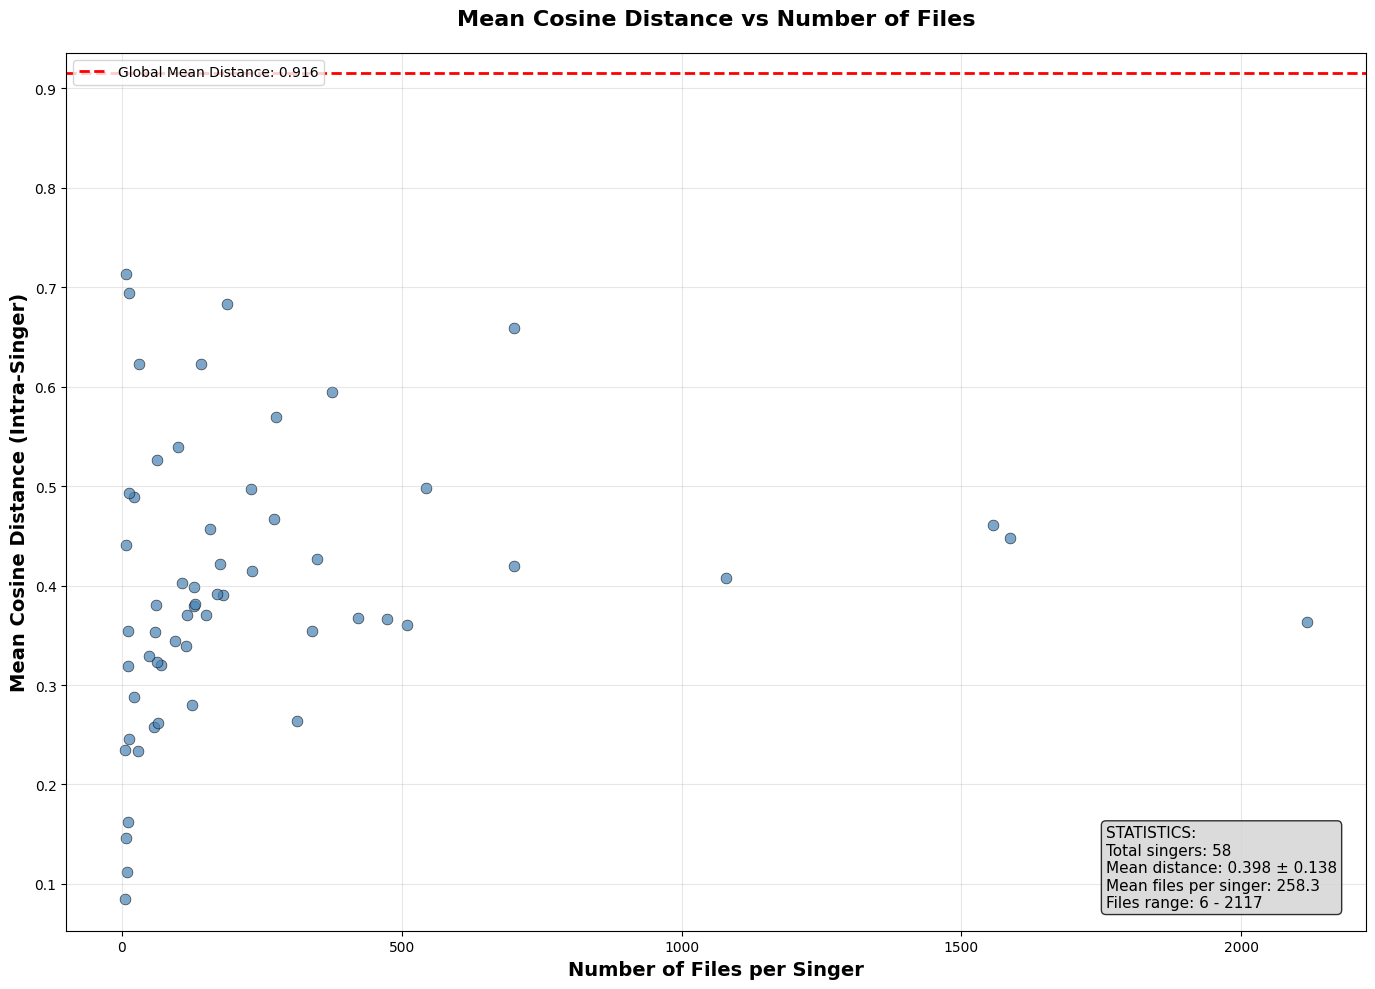


🔍 INSIGHTS:
Correlation between files and mean distance: 0.147
Singers below global mean (0.916): 58/58 (100.0%)
Singers above global mean: 0/58 (0.0%)
📉 Positive correlation: More files tend to have higher mean distance (less consistent)

🏆 EXTREME CASES:
Most consistent: id00049 (0.084 distance, 6 files)
Least consistent: id00047 (0.713 distance, 8 files)
Most files: id00043 (2117 files, 0.364 distance)


In [9]:
# Get data for ALL singers (set min_files=2 since you need at least 2 files to calculate distance)
all_singers_results = analyze_intra_singer_similarity(min_files=2)

plot_all_singers_distance_vs_files(all_singers_results)

In [ ]:
def plot_all_singers_distance_vs_files(results):
    """
    Plot mean cosine distance vs number of files for all singers in your results
    
    Args:
        results: Your existing results from analyze_intra_singer_similarity()
    """
    
    print(f"📊 Plotting data for {len(results)} singers")
    
    # Extract data for plotting
    num_files = [r['num_files'] for r in results]
    mean_distances = [r['mean_distance'] for r in results]
    singer_ids = [r['singer_id'] for r in results]
    
    # Create the plot
    plt.figure(figsize=(14, 10))
    
    # Scatter plot
    scatter = plt.scatter(num_files, mean_distances, alpha=0.7, s=60, c='steelblue', 
                         edgecolors='black', linewidth=0.5)
    
    # # Add horizontal line for global mean distance
    # global_mean_distance = 0.9157
    # plt.axhline(y=global_mean_distance, color='red', linestyle='--', linewidth=2, 
    #             label=f'Global Mean Distance: {global_mean_distance:.3f}')
    
    # Customize the plot
    plt.xlabel('Number of Files per Singer', fontsize=14, fontweight='bold')
    plt.ylabel('Mean Cosine Distance (Intra-Singer)', fontsize=14, fontweight='bold')
    plt.title(f'Mean Cosine Distance vs Number of Files', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    
    # Add legend for the horizontal line - MOVED TO TOP LEFT
    plt.legend(loc='upper left')
    
    # Add statistics as text
    mean_dist_overall = np.mean(mean_distances)
    std_dist_overall = np.std(mean_distances)
    mean_files_overall = np.mean(num_files)
    max_files = max(num_files)
    min_files = min(num_files)
    
    stats_text = f'STATISTICS:\n'
    stats_text += f'Total singers: {len(results)}\n'
    stats_text += f'Mean distance: {mean_dist_overall:.3f} ± {std_dist_overall:.3f}\n'
    stats_text += f'Mean files per singer: {mean_files_overall:.1f}\n'
    stats_text += f'Files range: {min_files} - {max_files}'
    
    plt.text(0.8, 0.12, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8),
             fontsize=11)
    
    # Set axis limits with some padding - ENSURE GLOBAL MEAN LINE IS VISIBLE
    x_margin = (max(num_files) - min(num_files)) * 0.05
    y_margin = (max(mean_distances) - min(mean_distances)) * 0.05
    
    # Make sure y-axis includes the global mean line
    y_min = min(min(mean_distances) - y_margin, global_mean_distance - 0.02)
    y_max = max(max(mean_distances) + y_margin, global_mean_distance + 0.02)
    
    plt.xlim(min(num_files) - x_margin, max(num_files) + x_margin)
    plt.ylim(y_min, y_max)
    
    # Debug info
    print(f"Y-axis range: {y_min:.3f} to {y_max:.3f}")
    print(f"Global mean line at: {global_mean_distance:.3f}")
    print(f"Data range: {min(mean_distances):.3f} to {max(mean_distances):.3f}")
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print(f"\n🔍 INSIGHTS:")
    correlation = np.corrcoef(num_files, mean_distances)[0, 1]
    print(f"Correlation between files and mean distance: {correlation:.3f}")
    
    # Compare to global mean
    below_global_mean = sum(1 for d in mean_distances if d < global_mean_distance)
    above_global_mean = len(mean_distances) - below_global_mean
    print(f"Singers below global mean ({global_mean_distance:.3f}): {below_global_mean}/{len(mean_distances)} ({below_global_mean/len(mean_distances)*100:.1f}%)")
    print(f"Singers above global mean: {above_global_mean}/{len(mean_distances)} ({above_global_mean/len(mean_distances)*100:.1f}%)")
    
    if correlation < -0.1:
        print("📈 Negative correlation: More files tend to have lower mean distance (more consistent)")
    elif correlation > 0.1:
        print("📉 Positive correlation: More files tend to have higher mean distance (less consistent)")
    else:
        print("➡️ Weak correlation: Number of files doesn't strongly affect consistency")
    
    # Show extremes
    best_consistency_idx = np.argmin(mean_distances)
    worst_consistency_idx = np.argmax(mean_distances)
    most_files_idx = np.argmax(num_files)
    
    print(f"\n🏆 EXTREME CASES:")
    print(f"Most consistent: {singer_ids[best_consistency_idx]} ({mean_distances[best_consistency_idx]:.3f} distance, {num_files[best_consistency_idx]} files)")
    print(f"Least consistent: {singer_ids[worst_consistency_idx]} ({mean_distances[worst_consistency_idx]:.3f} distance, {num_files[worst_consistency_idx]} files)")
    print(f"Most files: {singer_ids[most_files_idx]} ({num_files[most_files_idx]} files, {mean_distances[most_files_idx]:.3f} distance)")


📊 Plotting data for 6794717 singers


IndexError: invalid index to scalar variable.

In [10]:
# Analyze global embedding distribution (sampled for speed)
global_results = analyze_global_embedding_distribution(n_samples=2000)

✅ Connected to database successfully!
Mean norm 1372.348 ± 134.895


In [17]:
sample_random_pair_distance()

NameError: name 'sample_random_pair_distance' is not defined

In [18]:
# Force reload the module completely
import importlib
import sys

# Remove the module from cache if it exists
if 'view_data' in sys.modules:
    del sys.modules['view_data']

# Re-import everything
from view_data import *

# Check if the function is now available
print("Available functions:", [name for name in dir() if 'analyze_nearest' in name])

# Now try running it
nn_results = analyze_nearest_neighbors_accuracy(n_neighbors=5)

Available functions: ['analyze_nearest_neighbors_accuracy']
✅ Connected to database successfully!


NN accuracy (5 NN): 0.997 (14927/14979)


In [19]:
# Remove both outliers from the results
outliers_to_remove = ['id03933', 'id07215']
filtered_singer_stats = {k: v for k, v in nn_results['singer_stats'].items() if k not in outliers_to_remove}

print(f"Original singers: {len(nn_results['singer_stats'])}")
print(f"After removing outliers: {len(filtered_singer_stats)}")

# Check which outliers were actually in the results
for outlier in outliers_to_remove:
    if outlier in nn_results['singer_stats']:
        removed_stats = nn_results['singer_stats'][outlier]
        print(f"Removed {outlier} with {removed_stats['total_embeddings']} files and {removed_stats['accuracy']:.3f} accuracy")
    else:
        print(f"{outlier} was not in the results")

# Extract filtered data for plotting
accuracies = [stats['accuracy'] for stats in filtered_singer_stats.values()]
file_counts = [stats['total_embeddings'] for stats in filtered_singer_stats.values()]
singer_names = list(filtered_singer_stats.keys())

print(f"📊 Plotting data for {len(accuracies)} singers (excluding outliers)")
print(f"Accuracy range: {min(accuracies):.3f} - {max(accuracies):.3f}")
print(f"File count range: {min(file_counts)} - {max(file_counts)}")

# Create two plots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Plot 1: Histogram of accuracies (filtered)
ax1.hist(accuracies, bins=20, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Singers', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Singer Accuracies\n(Excluding Outliers)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add statistics text to histogram
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)
median_acc = np.median(accuracies)

stats_text = f'Statistics (filtered):\n'
stats_text += f'Mean: {mean_acc:.3f}\n'
stats_text += f'Median: {median_acc:.3f}\n'
stats_text += f'Std: {std_acc:.3f}\n'
stats_text += f'Min: {min(accuracies):.3f}\n'
stats_text += f'Max: {max(accuracies):.3f}'

ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8),
         fontsize=10)

# Plot 2: Accuracy vs Number of Files (filtered)
scatter = ax2.scatter(file_counts, accuracies, alpha=0.7, s=60, c='green', 
                     edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Number of Files per Singer', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Singer Accuracy vs Number of Files\n(Excluding Outliers)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add trend line for second plot
z = np.polyfit(file_counts, accuracies, 1)
p = np.poly1d(z)
x_trend = np.linspace(min(file_counts), max(file_counts), 100)
ax2.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, 
         label=f'Trend (slope: {z[0]:.4f})')
ax2.legend()

# Add correlation info
correlation = np.corrcoef(file_counts, accuracies)[0, 1]
ax2.text(0.98, 0.12, f'Correlation: {correlation:.3f}', transform=ax2.transAxes, 
         verticalalignment='bottom', horizontalalignment='right', 
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8),
         fontsize=10)

plt.tight_layout()
plt.show()

# Print insights with filtered data
print(f"\n🔍 FILTERED ACCURACY ANALYSIS (excluding {', '.join(outliers_to_remove)}):")
print(f"Average accuracy per singer: {mean_acc:.3f} ({mean_acc*100:.1f}%)")
print(f"Correlation between files and accuracy: {correlation:.3f}")

# Also calculate overall embedding-level accuracy excluding outliers
# Filter detailed results to exclude both outliers
filtered_detailed = [r for r in nn_results['detailed_results'] if r['target_singer'] not in outliers_to_remove]
filtered_correct = sum(1 for r in filtered_detailed if r['same_singer_found'])
filtered_total = len(filtered_detailed)
filtered_overall_accuracy = filtered_correct / filtered_total if filtered_total > 0 else 0

print(f"Overall embedding accuracy (filtered): {filtered_overall_accuracy:.3f} ({filtered_overall_accuracy*100:.1f}%)")
print(f"Original overall accuracy: {nn_results['accuracy']:.3f} ({nn_results['accuracy']*100:.1f}%)")
print(f"Improvement: {(filtered_overall_accuracy - nn_results['accuracy'])*100:.1f} percentage points")

# Show count of embeddings removed
original_embedding_count = len(nn_results['detailed_results'])
filtered_embedding_count = len(filtered_detailed)
removed_embedding_count = original_embedding_count - filtered_embedding_count

print(f"\nEmbeddings removed: {removed_embedding_count} out of {original_embedding_count}")

TypeError: 'float' object is not subscriptable

In [21]:
# Run analysis for different k values
k_values = [1, 3, 5]
results_by_k = {}

print("🔄 Running nearest neighbors analysis for different k values...")

for k in k_values:
    print(f"\n📊 Running analysis for top-{k}...")
    # Run the analysis (this will use your existing filtered dataset)
    nn_k_results = analyze_nearest_neighbors_accuracy(n_neighbors=k)
    
    # Filter out the outliers from the results
    outliers_to_remove = []
    filtered_singer_stats = {singer: stats for singer, stats in nn_k_results['singer_stats'].items() 
                           if singer not in outliers_to_remove}
    
    # Extract accuracies and same-singer counts for this k
    accuracies = [stats['accuracy'] for stats in filtered_singer_stats.values()]
    same_singer_counts = [stats['avg_same_singer_count'] for stats in filtered_singer_stats.values()]
    
    # Calculate statistics
    results_by_k[k] = {
        'mean': np.mean(accuracies),
        'median': np.median(accuracies),
        'std': np.std(accuracies),
        'min': np.min(accuracies),
        'max': np.max(accuracies),
        'avg_same_singer': np.mean(same_singer_counts)
    }

# Create the summary table
print(f"\n📋 SUMMARY TABLE: Nearest Neighbors Accuracy Statistics")
print("="*95)
print(f"{'Metric':<15} | {'Mean':<8} | {'Median':<8} | {'Std':<8} | {'Min':<8} | {'Max':<8} | {'Avg Same-Singer':<14}")
print("-"*95)

for k in k_values:
    stats = results_by_k[k]
    print(f"{'Top-' + str(k) + ' Accuracy':<15} | "
          f"{stats['mean']:<8.3f} | "
          f"{stats['median']:<8.3f} | "
          f"{stats['std']:<8.3f} | "
          f"{stats['min']:<8.3f} | "
          f"{stats['max']:<8.3f} | "
          f"{stats['avg_same_singer']:<14.3f}")

print("\n📊 INSIGHTS:")
print(f"Best mean accuracy: Top-{max(k_values, key=lambda k: results_by_k[k]['mean'])} "
      f"({results_by_k[max(k_values, key=lambda k: results_by_k[k]['mean'])]['mean']:.3f})")

print(f"Most consistent (lowest std): Top-{min(k_values, key=lambda k: results_by_k[k]['std'])} "
      f"(std: {results_by_k[min(k_values, key=lambda k: results_by_k[k]['std'])]['std']:.3f})")

print(f"Highest avg same-singer neighbors: Top-{max(k_values, key=lambda k: results_by_k[k]['avg_same_singer'])} "
      f"({results_by_k[max(k_values, key=lambda k: results_by_k[k]['avg_same_singer'])]['avg_same_singer']:.3f})")

# Show improvement from top-1 to top-5
improvement = results_by_k[5]['mean'] - results_by_k[1]['mean']
same_singer_improvement = results_by_k[5]['avg_same_singer'] - results_by_k[1]['avg_same_singer']
print(f"Improvement from Top-1 to Top-5:")
print(f"  Accuracy: +{improvement:.3f} ({improvement*100:.1f} percentage points)")
print(f"  Avg Same-Singer: +{same_singer_improvement:.3f}")

🔄 Running nearest neighbors analysis for different k values...

📊 Running analysis for top-1...
✅ Connected to database successfully!


NN accuracy (1 NN): 0.983 (14725/14979)


TypeError: 'float' object is not subscriptable